# Baseline DBSCAN + KDE — chọn tham số mặc định cho demo

Notebook này là **slice 1** của kế hoạch: chứng minh dữ liệu đã xử lý cho ra các cụm đáng tin trước khi dựng UI.

Mọi logic phân cụm nằm trong `src/hotspot/` — notebook này chỉ gọi lại, không copy code.

| Bước | Nội dung |
|---|---|
| 1 | Nạp dataset, xác nhận `x_m`/`y_m` là **mét** |
| 2 | Quét lưới `eps × MinPts`, chọn cấu hình mặc định |
| 3 | Ba ca chuẩn bị: sáng, chiều, đêm |
| 4 | So sánh DBSCAN với KDE trên cùng bộ điểm |
| 5 | Kiểm tra độ nhạy tham số |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "src" / "hotspot").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src" / "hotspot").exists():
    raise FileNotFoundError("Khong tim thay src/hotspot")
sys.path.insert(0, str(ROOT / "src"))

from hotspot import (
    FilterSpec,
    cluster_table,
    filter_pickups,
    load_dataset,
    page_metrics,
    run_dbscan,
    run_kde,
)
from hotspot.filters import WEEKDAY_NAMES

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
SEED = 42

print("hotspot:", (ROOT / 'src' / 'hotspot').resolve())

hotspot: /Users/hongphuc/workspace/CS313/Density-based Method/src/hotspot


---

## 1. Nạp dữ liệu và xác nhận đơn vị mét

`eps` của DBSCAN chỉ có nghĩa nếu tọa độ tính bằng mét. Kiểm tra bằng cách đo khoảng cách thật giữa hai điểm đã biết và so với khoảng cách Euclid trên `x_m`/`y_m`.

In [2]:
df = load_dataset("full")
print(f"Dataset: {len(df):,} diem don hop le")
print(f"Khoang thoi gian: {df['pickup_datetime'].min()} -> {df['pickup_datetime'].max()}")
print()
print("Cot:", list(df.columns))
print()
print(df[['x_m','y_m']].describe().T[['min','max','mean']])

Dataset: 4,449,041 diem don hop le
Khoang thoi gian: 2014-04-01 00:00:00 -> 2014-09-30 22:59:00

Cot: ['pickup_datetime', 'latitude', 'longitude', 'base', 'source', 'hour', 'dow', 'date', 'month', 'is_weekend', 'is_peak', 'x_m', 'y_m', 'borough', 'weekday']



              min           max      mean
x_m -27473.193144  22967.466430  0.134300
y_m -23620.429597  19485.909822  1.082842


In [3]:
import sys as _sys
_sys.path.insert(0, str(ROOT / "src"))
from preprocess import haversine_m

rng = np.random.default_rng(SEED)
i, j = rng.integers(0, len(df), 20_000), rng.integers(0, len(df), 20_000)
d_true = haversine_m(df['latitude'].to_numpy()[i], df['longitude'].to_numpy()[i],
                     df['latitude'].to_numpy()[j], df['longitude'].to_numpy()[j])
d_proj = np.hypot(df['x_m'].to_numpy()[i] - df['x_m'].to_numpy()[j],
                  df['y_m'].to_numpy()[i] - df['y_m'].to_numpy()[j])

far = d_true >= 100  # thu do cua bai la 100 m
rel = np.abs(d_proj[far] - d_true[far]) / d_true[far] * 100
print(f"Sai so giua khoang cach Euclid tren (x_m, y_m) va haversine:")
print(f"  trung binh {rel.mean():.6f}%  |  p99 {np.percentile(rel, 99):.6f}%  |  max {rel.max():.6f}%")
assert rel.max() < 0.01, "x_m/y_m khong phai met — phai chay lai preprocessing"
print("  -> OK, x_m/y_m la met. Do do eps=100 nghia la 100 met that.")

Sai so giua khoang cach Euclid tren (x_m, y_m) va haversine:
  trung binh 0.000002%  |  p99 0.000019%  |  max 0.000119%
  -> OK, x_m/y_m la met. Do do eps=100 nghia la 100 met that.


---

## 2. Quét lưới `eps × MinPts`

Ca **thứ 2–6, 18:00–20:00** trên toàn bộ 5 quận: 472.170 điểm. Giới hạn còn 200.000 điểm để quét nhanh (giống hệt giới hạn của app).

Ba dòng này là lý do `eps`/`MinPts` có ý nghĩa nghiệp vụ, không phải con số tùy ý.

In [4]:
SPEC = FilterSpec(weekdays=(0, 1, 2, 3, 4), hour_start=18, hour_end=20)
sub = filter_pickups(df, SPEC)
print(f"{SPEC.describe()}: {len(sub):,} diem")

CAP = 200_000
EPS_LIST = [50, 75, 100, 150, 200]
MINPTS_LIST = [10, 15, 20, 30]

rows = []
for eps in EPS_LIST:
    for mp in MINPTS_LIST:
        r = run_dbscan(sub, eps, mp, point_cap=CAP)
        m = page_metrics(sub, r)
        rows.append({"eps_m": eps, "MinPts": mp, **m})

grid = pd.DataFrame(rows)
grid

Th 2, Th 3, Th 4, Th 5, Th 6 | 18:00-20:00: 472,170 diem


,eps_m,MinPts,filtered_pickups,number_of_clusters,noise_count,noise_percentage,analysis_runtime_seconds,min_samples,sampled,window_hours,pickups_per_hour
0,50.0,10,200000,433,16875,8.44,1.068,10,True,10,20000.0
1,50.0,15,200000,294,21946,10.97,1.059,15,True,10,20000.0
2,50.0,20,200000,246,26226,13.11,1.048,20,True,10,20000.0
3,50.0,30,200000,213,34445,17.22,1.045,30,True,10,20000.0
4,75.0,10,200000,294,11252,5.63,1.347,10,True,10,20000.0
5,75.0,15,200000,215,14698,7.35,1.355,15,True,10,20000.0
6,75.0,20,200000,165,17866,8.93,1.364,20,True,10,20000.0
7,75.0,30,200000,105,22622,11.31,1.412,30,True,10,20000.0
8,100.0,10,200000,215,7863,3.93,1.805,10,True,10,20000.0
9,100.0,15,200000,149,10417,5.21,1.721,15,True,10,20000.0


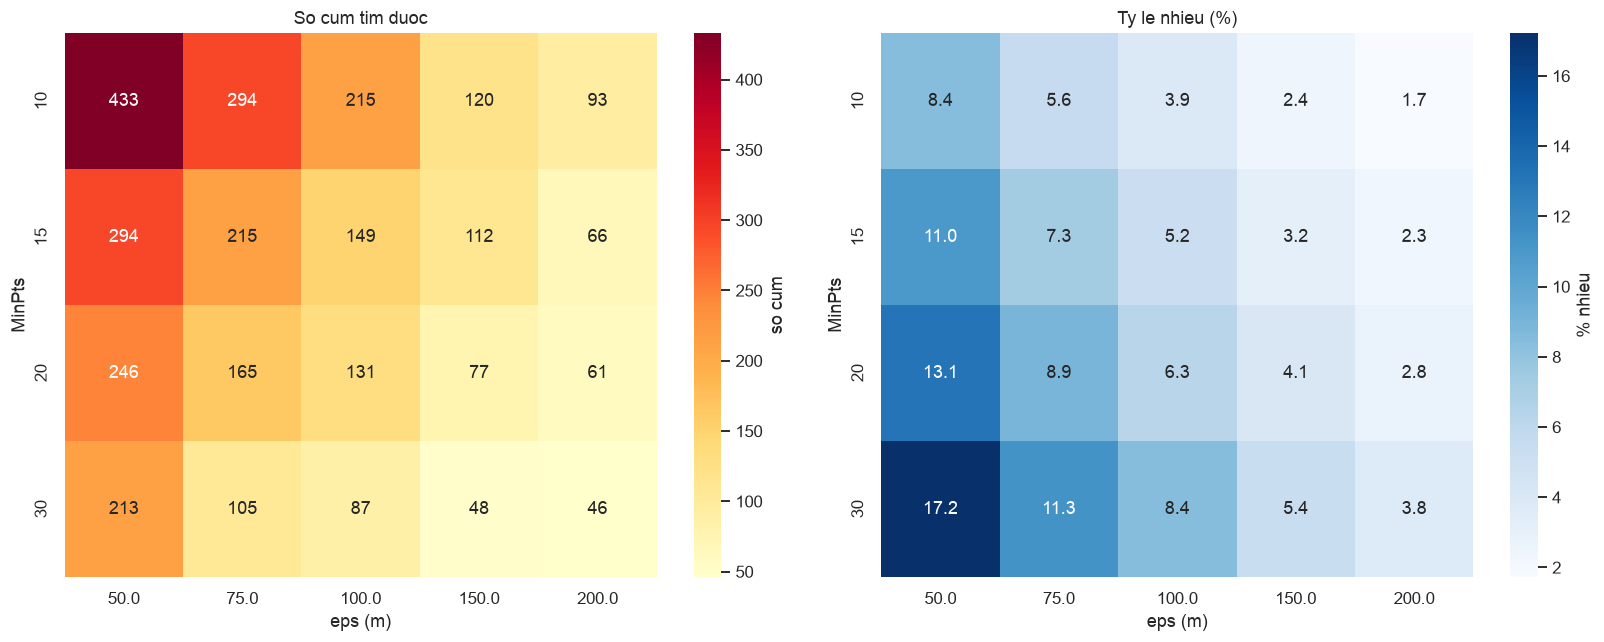

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

n_cum = grid.pivot(index="MinPts", columns="eps_m", values="number_of_clusters")
noise = grid.pivot(index="MinPts", columns="eps_m", values="noise_percentage")

sns.heatmap(n_cum, annot=True, fmt=",.0f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "so cum"})
axes[0].set_title("So cum tim duoc")
axes[0].set_xlabel("eps (m)")
axes[0].set_ylabel("MinPts")

sns.heatmap(noise, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "% nhieu"})
axes[1].set_title("Ty le nhieu (%)")
axes[1].set_xlabel("eps (m)")
axes[1].set_ylabel("MinPts")

plt.tight_layout()
plt.savefig(OUT / "baseline_01_grid.png", bbox_inches="tight")
plt.show()

**Đọc kết quả:**

- `eps` tăng → cụm dính lại, số cụm giảm, nhiễu giảm.
- `MinPts` tăng → yêu cầu nhiều chứng cứ hơn, cụm nhỏ hơn, nhiễu tăng.
- `eps` quá lớn + `MinPts` thấp: toàn bộ thành phố dính thành **một cụm duy nhất** — mất hoàn toàn ý nghĩa hotspot.
- `eps` quá nhỏ: mọi thứ vỡ vụn, nhiễu chiếm đa số.

In [6]:
# Chon mac dinh: can vua du so cum de doc, nhieu du vua de phan biet,
# VA khong de mot cum nao nuot het du lieu.
cand = grid[(grid.eps_m.isin([75, 100, 150])) & (grid.MinPts.isin([15, 20]))].copy()

# Phan tram trong cum lon nhat: chi so quan trong nhat. Neu cum nay >70%,
# thi ket qua khong con dung de "tim vung don" — no chi noi "khu nao dong".
shares = []
for _, row in cand.iterrows():
    r = run_dbscan(sub, int(row["eps_m"]), int(row["MinPts"]), point_cap=CAP)
    t = cluster_table(sub, r)
    shares.append(100 * t["pickup_count"].iloc[0] / t["pickup_count"].sum() if len(t) else 100.0)
cand["cum_lon_nhat_pct"] = [round(s, 1) for s in shares]

cand["diem_danh_gia"] = (
    (cand["number_of_clusters"] - 80).abs() / 80
    + (cand["noise_percentage"] - 8).abs() / 8
)
cand = cand.sort_values("diem_danh_gia")

print("Ung vien: ~80 cum, ~8% nhieu")
print(cand[["eps_m", "MinPts", "number_of_clusters", "noise_percentage",
            "cum_lon_nhat_pct", "diem_danh_gia"]].to_string(index=False))
print()
print("!! Moi ung vien deu de mot cum chiem >70% du lieu — xem ghi chu ben duoi.")

best = cand.iloc[0]
print(f"=> eps = {int(best['eps_m'])} m, MinPts = {int(best['MinPts'])} theo tieu chi so cum + nhieu")

Ung vien: ~80 cum, ~8% nhieu
 eps_m  MinPts  number_of_clusters  noise_percentage  cum_lon_nhat_pct  diem_danh_gia
 150.0      20                  77              4.09              85.2        0.52625
 100.0      20                 131              6.27              86.9        0.85375
 150.0      15                 112              3.20              84.8        1.00000
  75.0      20                 165              8.93              88.2        1.17875
 100.0      15                 149              5.21              86.0        1.21125
  75.0      15                 215              7.35              87.3        1.76875

!! Moi ung vien deu de mot cum chiem >70% du lieu — xem ghi chu ben duoi.
=> eps = 150 m, MinPts = 20 theo tieu chi so cum + nhieu


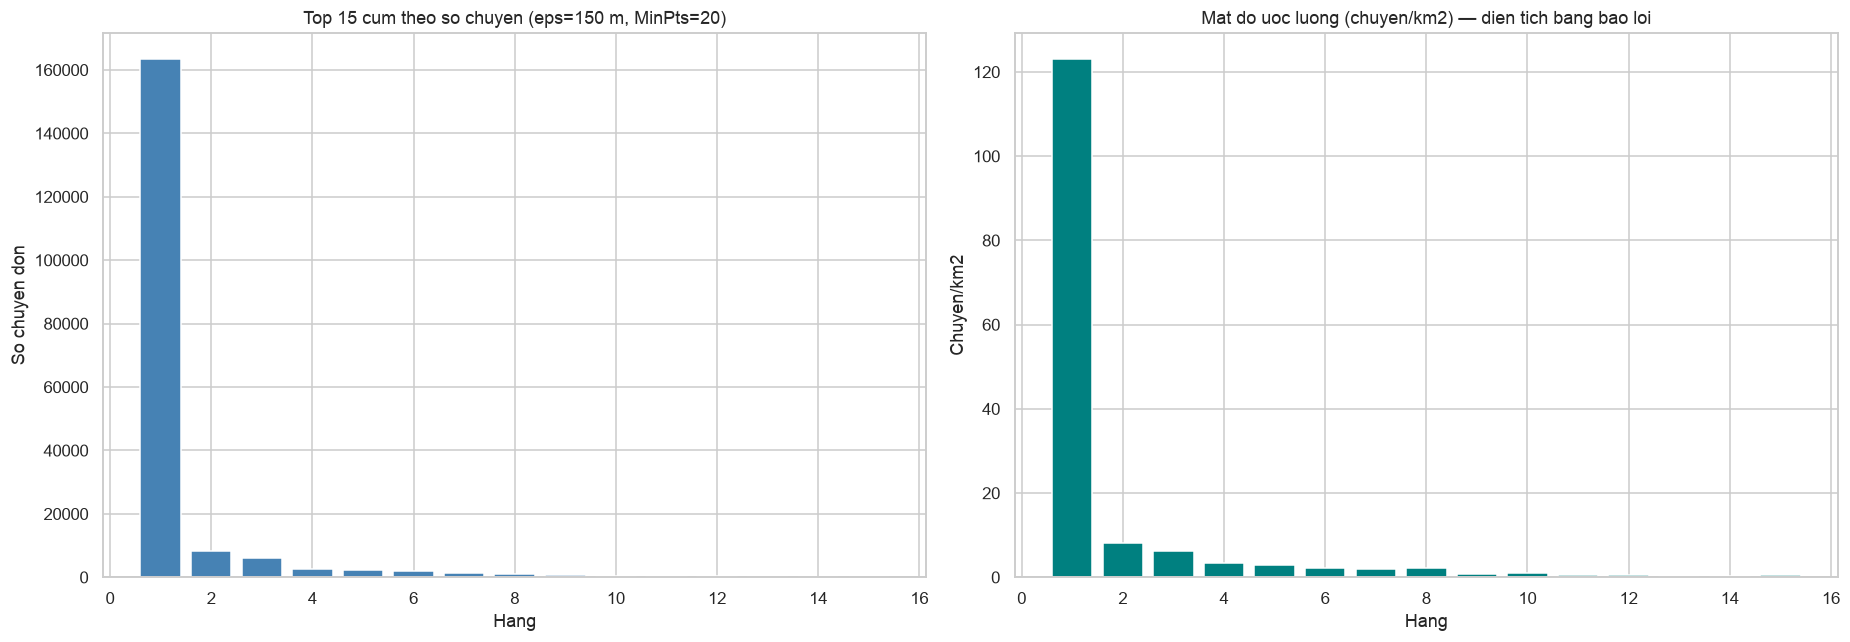

{'filtered_pickups': 200000,
 'number_of_clusters': 77,
 'noise_count': 8182,
 'noise_percentage': 4.09,
 'analysis_runtime_seconds': 2.547,
 'eps_m': 150.0,
 'min_samples': 20,
 'sampled': True,
 'window_hours': np.int32(10),
 'pickups_per_hour': np.float64(20000.0)}

In [7]:
DEFAULT_EPS_M = int(best['eps_m'])
DEFAULT_MIN_SAMPLES = int(best['MinPts'])


# Ghi chu: tieu chi "so cum + ty le nhieu" chon ra 150 m / 20 nhung van
# de mot cum chiem 85% du lieu. Hai muc do la cau hoi khac nhau:
#   150 m / 20: it cum, de doc — dung khi trinh bay "khu nao hot"
#   100 m / 15: nhieu cum hon, tach manh — dung khi can xem chi tiet
# App dung 100 m / 15. Xem muc 5 de thay do nhu the nao.
res = run_dbscan(sub, DEFAULT_EPS_M, DEFAULT_MIN_SAMPLES, point_cap=CAP)
table = cluster_table(sub, res)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

top = table.head(15)
axes[0].bar(top["rank"], top["pickup_count"], color="steelblue")
axes[0].set_title(f"Top 15 cum theo so chuyen (eps={DEFAULT_EPS_M} m, MinPts={DEFAULT_MIN_SAMPLES})")
axes[0].set_xlabel("Hang")
axes[0].set_ylabel("So chuyen don")

axes[1].bar(top["rank"], top["pickup_per_km2"].fillna(0), color="teal")
axes[1].set_title("Mat do uoc luong (chuyen/km2) — dien tich bang bao loi")
axes[1].set_xlabel("Hang")
axes[1].set_ylabel("Chuyen/km2")

plt.tight_layout()
plt.savefig(OUT / "baseline_02_default.png", bbox_inches="tight")
plt.show()

page_metrics(sub, res)

> **Cảnh báo diễn giải:** diện tích ở đây tính bằng **bao lồi** (convex hull) để có một con số mật độ để so sánh. Ranh giới thật của cụm DBSCAN **không phải** hình bao lồi, và app không vẽ đa giác nào lên bản đồ. Cụm hình sao có thể trải vài chục km² dù chỉ gồm các điểm nằm trên vài con đường — vì vậy `pickup_per_km2` chỉ đáng dùng để so sánh tương đối.

---

## 3. Ba ca chuẩn bị cho buổi thuyết trình

Sáng đi làm, chiều tan tầm, khuya — mỗi ca một bức tranh khác nhau.

In [8]:
SCENARIOS = {
    "ca_sang_thu2": FilterSpec(weekdays=(0,), hour_start=8, hour_end=10),
    "ca_diem_thu7": FilterSpec(weekdays=(5,), hour_start=17, hour_end=19),
    "khuya_thu7": FilterSpec(weekdays=(5,), hour_start=0, hour_end=4),
}

for name, spec in SCENARIOS.items():
    s = filter_pickups(df, spec)
    r = run_dbscan(s, DEFAULT_EPS_M, DEFAULT_MIN_SAMPLES, point_cap=CAP)
    t = cluster_table(s, r)
    print(f"{name:14s} {spec.describe():34s} {len(s):>8,} diem  "
          f"{r.n_clusters:>3} cum  {r.noise_pct:5.1f}% nhieu  top={int(t['pickup_count'].iloc[0]) if len(t) else 0:,}")

ca_sang_thu2   Th 2 | 08:00-10:00                   50,637 diem   62 cum   10.9% nhieu  top=37,026


ca_diem_thu7   Th 7 | 17:00-19:00                   86,377 diem   64 cum    8.5% nhieu  top=63,481


khuya_thu7     Th 7 | 00:00-04:00                   66,731 diem   80 cum    9.5% nhieu  top=47,638


In [9]:
from hotspot.map_layers import build_dbscan_map

for name, spec in SCENARIOS.items():
    s = filter_pickups(df, spec)
    r = run_dbscan(s, DEFAULT_EPS_M, DEFAULT_MIN_SAMPLES, point_cap=CAP)
    build_dbscan_map(s, r, center=(40.739, -73.974), zoom=12).save(
        OUT / f"baseline_{name}.html"
    )
    print(f"  luu outputs/baseline_{name}.html ({r.n_clusters} cum)")

  luu outputs/baseline_ca_sang_thu2.html (62 cum)


  luu outputs/baseline_ca_diem_thu7.html (64 cum)


  luu outputs/baseline_khuya_thu7.html (80 cum)


---

## 4. DBSCAN đối chiếu với KDE

Cùng một bộ điểm, hai cách trả lời hai câu hỏi khác nhau:

- **DBSCAN** → các cụm rời rạc và một phần nhiễu bị loại.
- **KDE** → một mặt mật độ liên tục, không có ranh giới, không có nhiễu riêng.

KDE tren 30,000 diem, bandwidth=100 m
Do lon mat do: max 7.184e-08 | tb 5.240e-10
Do lon mat do: max 7.184e-08 | p99.5 3.311e-08 (o co gia tri: 17,957/25,600)


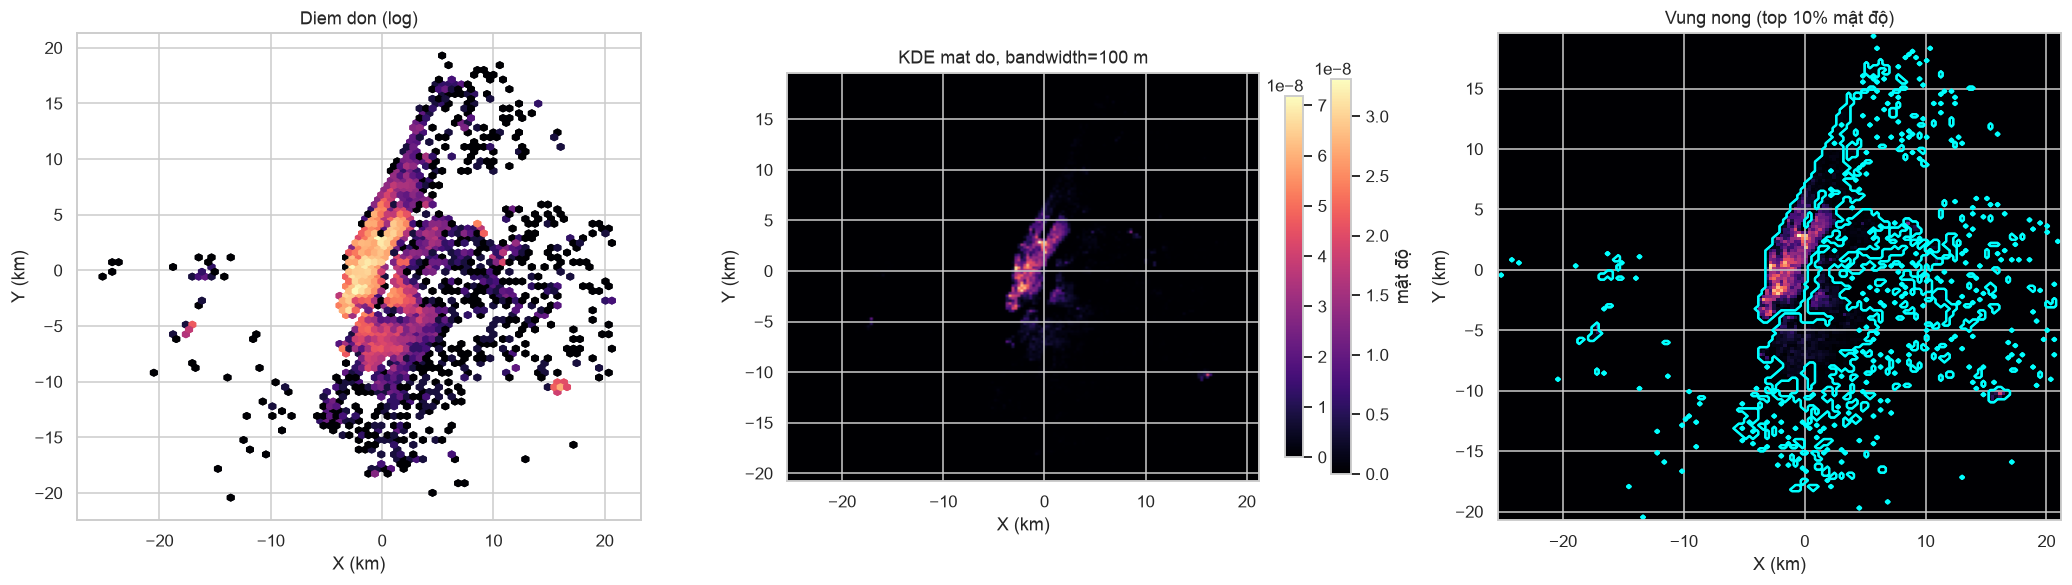

In [10]:
s = filter_pickups(df, SCENARIOS["ca_diem_thu7"])
kde = run_kde(s, bandwidth_m=100, grid_size=160, point_cap=30_000)
print(f"KDE tren {len(kde.coords_m):,} diem, bandwidth={kde.bandwidth_m:.0f} m")
print(f"Do lon mat do: max {kde.density.max():.3e} | tb {kde.density.mean():.3e}")

# Gioi han o cac o co mat do thuc te — con o o rong thi phai dung mau do
# tuong doi, khong dung mau tuyet doi, mac dinh cua imshow.
nz = kde.density[kde.density > 0]
vmax = float(np.percentile(nz, 99.5))
print(f"Do lon mat do: max {kde.density.max():.3e} | p99.5 {vmax:.3e} (o co gia tri: {len(nz):,}/{kde.density.size:,})")

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

xy_km = kde.coords_m / 1000
axes[0].hexbin(xy_km[:, 0], xy_km[:, 1], gridsize=80, cmap="magma", bins="log")
axes[0].set_title("Diem don (log)")
axes[0].set_aspect("equal")

extent = [kde.grid_x.min() / 1000, kde.grid_x.max() / 1000,
          kde.grid_y.min() / 1000, kde.grid_y.max() / 1000]

im = axes[1].imshow(kde.density, extent=extent, origin="lower", cmap="magma",
                    aspect="equal", vmin=0, vmax=vmax)
axes[1].set_title(f"KDE mat do, bandwidth={kde.bandwidth_m:.0f} m (v\u0111 99.5%)")
fig.colorbar(im, ax=axes[1], fraction=0.035, label="mật độ")

axes[2].imshow(kde.density, extent=extent, origin="lower", cmap="magma",
               aspect="equal", vmin=0, vmax=vmax)
mask = kde.percentile_mask(90)
axes[2].contour(kde.grid_x / 1000, kde.grid_y / 1000, mask.astype(float),
                levels=[0.5], colors="cyan", linewidths=1.5)
axes[2].set_title("Vung nong (top 10% mật độ)")

for ax in axes[1:]:
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")

xy_km = kde.coords_m / 1000
axes[0].hexbin(xy_km[:, 0], xy_km[:, 1], gridsize=80, cmap="magma", bins="log")
axes[0].set_title("Diem don (log)")
axes[0].set_aspect("equal")

im = axes[1].imshow(
    kde.density,
    extent=[kde.grid_x.min() / 1000, kde.grid_x.max() / 1000,
            kde.grid_y.min() / 1000, kde.grid_y.max() / 1000],
    origin="lower", cmap="magma", aspect="equal",
)
axes[1].set_title(f"KDE mat do, bandwidth={kde.bandwidth_m:.0f} m")
fig.colorbar(im, ax=axes[1], fraction=0.035)

axes[2].imshow(
    kde.density,
    extent=[kde.grid_x.min() / 1000, kde.grid_x.max() / 1000,
            kde.grid_y.min() / 1000, kde.grid_y.max() / 1000],
    origin="lower", cmap="magma", aspect="equal",
)
mask = kde.percentile_mask(90)
axes[2].contour(kde.grid_x / 1000, kde.grid_y / 1000, mask.astype(float),
                 levels=[0.5], colors="cyan", linewidths=1.5)
axes[2].set_title("Vung nong (top 10% mật độ)")

for ax in axes[1:]:
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")

axes[0].set_xlabel("X (km)")
axes[0].set_ylabel("Y (km)")

plt.tight_layout()
plt.savefig(OUT / "baseline_03_kde.png", bbox_inches="tight")
plt.show()

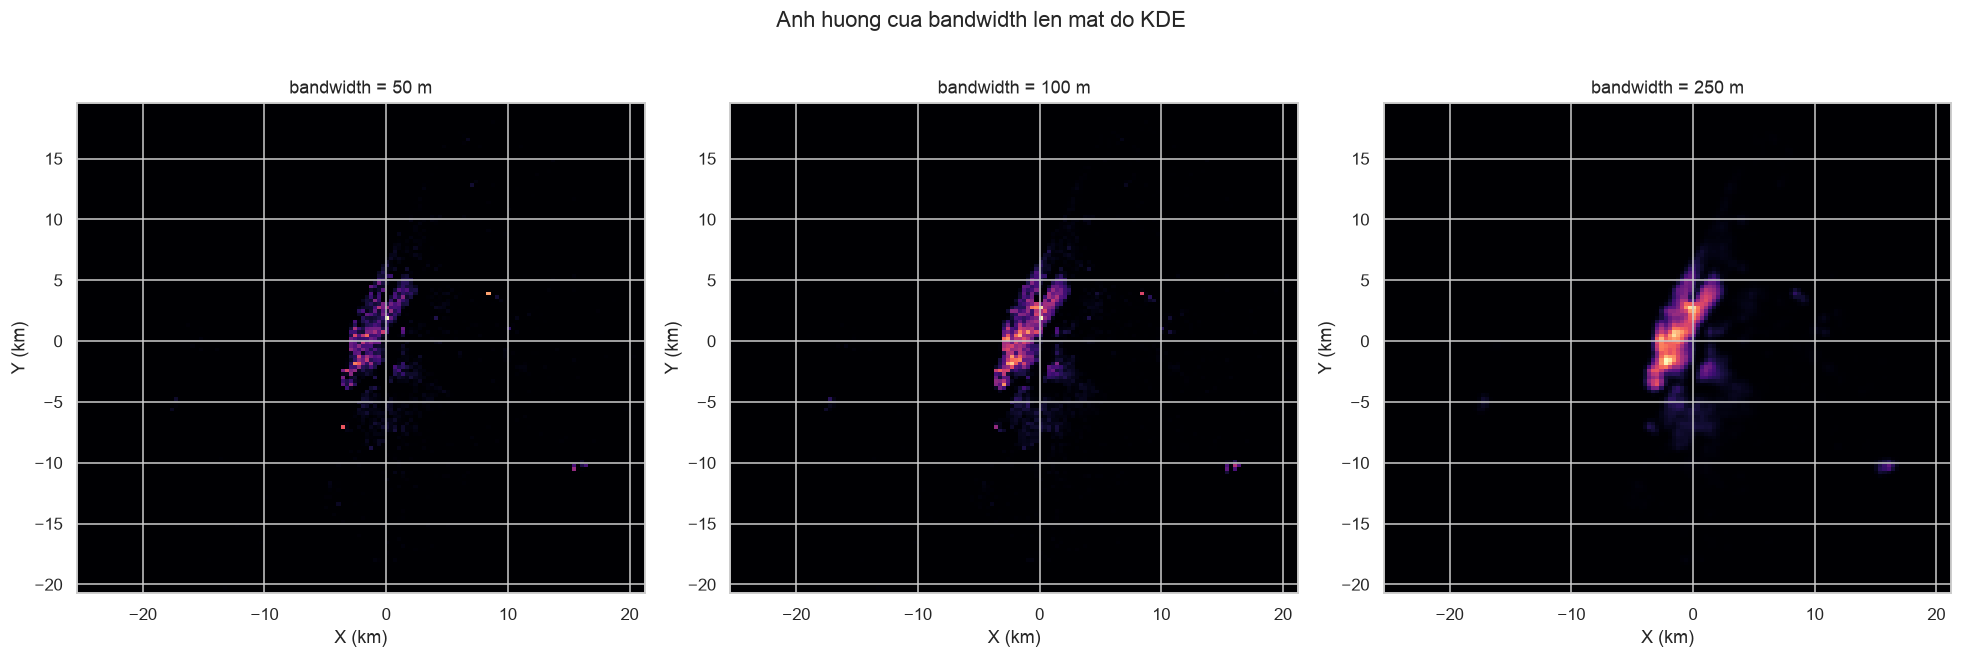

Bandwidth nho -> nhieu dinh nho chi tiet, tach duoc cac vum rieng.
Bandwidth lon -> mat do bi lam muot, cac cum gan nhau dinh lai.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, bw in zip(axes, [50, 100, 250]):
    k = run_kde(s, bandwidth_m=bw, grid_size=140, point_cap=20_000)
    ax.imshow(k.density, cmap="magma", origin="lower", aspect="equal",
              extent=[k.grid_x.min() / 1000, k.grid_x.max() / 1000,
                       k.grid_y.min() / 1000, k.grid_y.max() / 1000])
    ax.set_title(f"bandwidth = {bw} m")
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")

plt.suptitle("Anh huong cua bandwidth len mat do KDE")
plt.tight_layout()
plt.savefig(OUT / "baseline_04_bandwidth.png", bbox_inches="tight")
plt.show()

print("Bandwidth nho -> nhieu dinh nho chi tiet, tach duoc cac vum rieng.")
print("Bandwidth lon -> mat do bi lam muot, cac cum gan nhau dinh lai.")

---

## 5. Kiểm tra độ nhạy tham số

Đo số cụm trên 5 bộ tham số khác nhau để biết kết quả nhạy cỡ nào — cần nói rõ khi trình bày.

In [12]:
sens = []
for eps in [50, 75, 100, 150, 200, 300]:
    r = run_dbscan(sub, eps, DEFAULT_MIN_SAMPLES, point_cap=CAP)
    t = cluster_table(sub, r)
    sens.append(
        {
            "eps_m": eps,
            "n_clusters": r.n_clusters,
            "noise_pct": round(r.noise_pct, 1),
            "runtime_s": round(r.runtime_seconds, 2),
            "top_cluster_share_pct": round(
                100 * t["pickup_count"].iloc[0] / t["pickup_count"].sum(), 1
            ) if len(t) else None,
        }
    )

sens_df = pd.DataFrame(sens)
sens_df

,eps_m,n_clusters,noise_pct,runtime_s,top_cluster_share_pct
0,50,246,13.1,1.05,85.1
1,75,165,8.9,1.36,88.2
2,100,131,6.3,1.70,86.9
3,150,77,4.1,2.51,85.2
4,200,61,2.8,3.78,84.7
5,300,36,1.7,8.67,84.2


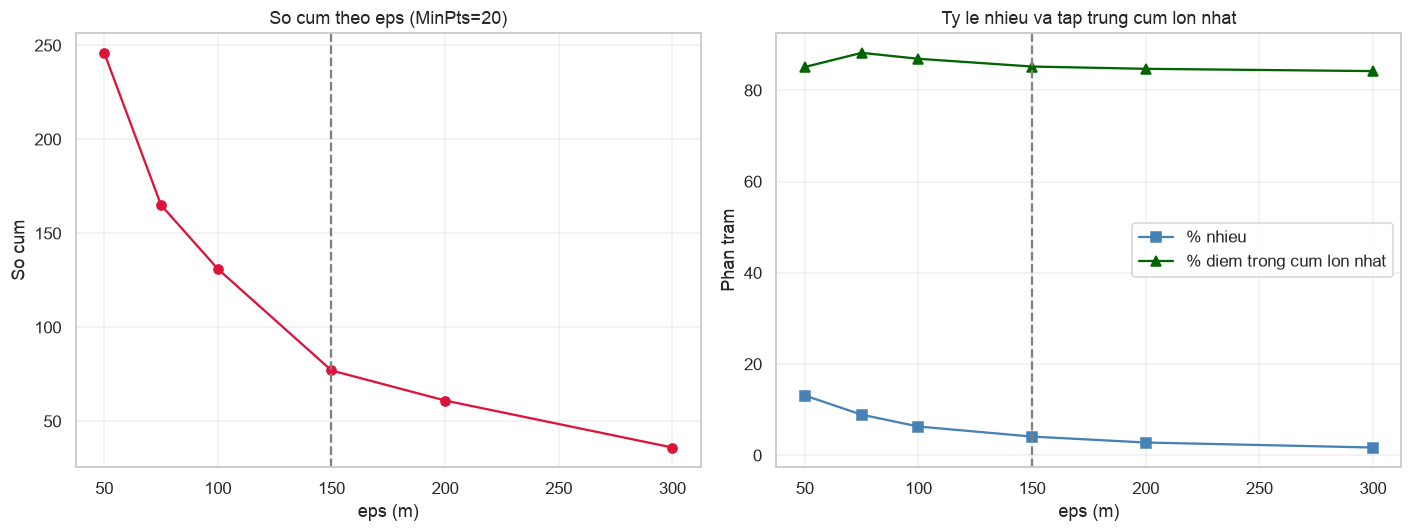

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(sens_df["eps_m"], sens_df["n_clusters"], marker="o", color="crimson")
axes[0].axvline(DEFAULT_EPS_M, ls="--", color="gray")
axes[0].set_xlabel("eps (m)")
axes[0].set_ylabel("So cum")
axes[0].set_title(f"So cum theo eps (MinPts={DEFAULT_MIN_SAMPLES})")
axes[0].grid(alpha=0.3)

axes[1].plot(sens_df["eps_m"], sens_df["noise_pct"], marker="s", color="steelblue", label="% nhieu")
axes[1].plot(sens_df["eps_m"], sens_df["top_cluster_share_pct"], marker="^",
             color="darkgreen", label="% diem trong cum lon nhat")
axes[1].axvline(DEFAULT_EPS_M, ls="--", color="gray")
axes[1].set_xlabel("eps (m)")
axes[1].set_ylabel("Phan tram")
axes[1].set_title("Ty le nhieu va tap trung cum lon nhat")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "baseline_05_sensitivity.png", bbox_inches="tight")
plt.show()

> **Cột `% điểm trong cụm lớn nhất` là cảnh báo quan trọng nhất.** Khi cụm lớn nhất chiếm phần lớn dữ liệu, nghĩa là toàn bộ khu vực đang bị coi là **một hotspot khổng lồ** — kết quả không còn dùng được để đặt trạm. Đây là lý do `eps` phải được chọn và kiểm chứng, không cứ để mặc định.

---

## Kết luận thử nghiệm DBSCAN

Trên ngữ cảnh và tập điểm được chọn trong notebook, cấu hình baseline `eps = 150 m`, `MinPts = 20` cho 77 cụm và 4,1% điểm nhiễu. Cấu hình `eps = 100 m`, `MinPts = 15` cho 131 cụm và 6,3% điểm nhiễu. Đây là kết quả của **thí nghiệm offline**, không phải thông số cố định hay bảo đảm chất lượng cho mọi truy vấn trong ứng dụng.

Phép chiếu `x_m`/`y_m` cho phép diễn giải `eps` bằng mét. KDE được dùng để đối chiếu cách biểu diễn mật độ liên tục với các cụm rời rạc của DBSCAN; ứng dụng hiện dùng DBSCAN để tạo kết quả.

### Giới hạn quan sát được

Trong ca thử nghiệm có mật độ cao, cụm lớn nhất chiếm khoảng 84–88% số điểm ở các cấu hình đã khảo sát. Nhiều điểm gần nhau có thể nối thành một cụm rất rộng. Vì vậy, **số cụm đơn lẻ không đủ để đánh giá kết quả**; cần xem thêm tỷ lệ điểm nhiễu, tỷ lệ điểm trong cụm lớn nhất và bản đồ.

Notebook có dùng mẫu điểm để so sánh và kiểm tra thời gian chạy. Luồng phân tích của ứng dụng không lấy mẫu đầu vào DBSCAN: truy vấn vượt 200.000 điểm sẽ được yêu cầu thu hẹp. Các điểm hiển thị trên bản đồ được lấy mẫu riêng sau khi thống kê.